In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.head())
print(train.info())
print(train.describe())

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  
<c

In [5]:
print(train.isnull().sum())

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


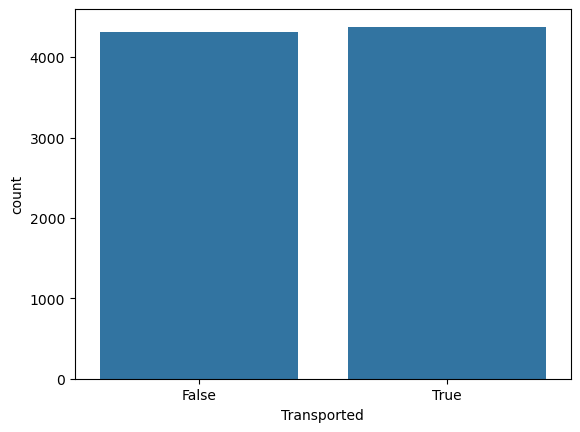

In [7]:
sns.countplot(x="Transported", data=train)
plt.show()

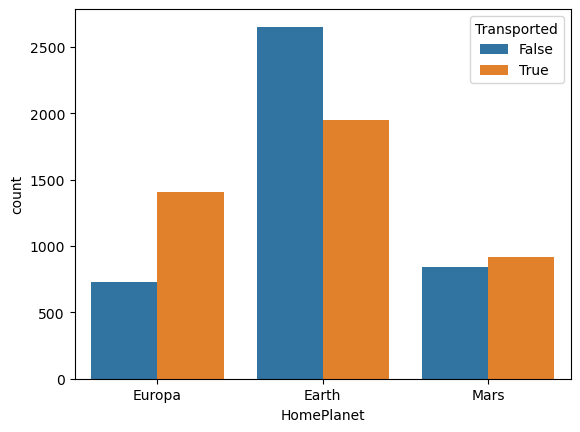

In [8]:
sns.countplot(x="HomePlanet", hue="Transported", data=train)
plt.show()

In [9]:
train.fillna(method='ffill', inplace=True)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_15840\2522684920.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train.fillna(method='ffill', inplace=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_15840\2522684920.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train.fillna(method='ffill', inplace=True)


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in train.select_dtypes(include="object").columns:
    train[col] = le.fit_transform(train[col].astype(str))

In [11]:
X = train.drop("Transported", axis=1)
y = train["Transported"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_val, y_val))

Accuracy: 0.7165037377803335


In [14]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

print("Accuracy:", nb_model.score(X_val, y_val))

Accuracy: 0.6940770557791834


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

print("Accuracy:", rf.score(X_val, y_val))

Accuracy: 0.7780333525014376


In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in test.select_dtypes(include="object").columns:
    test[col] = le.fit_transform(test[col].astype(str))

In [18]:
predictions = rf.predict(test)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Transported": predictions
})

submission.to_csv("submission.csv", index=False)

In [20]:
submission.to_csv("submission.csv", index=False)

In [21]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"].astype(str),
    "Transported": predictions
})

submission.to_csv("submission.csv", index=False)

In [22]:
print(submission.dtypes)

PassengerId    object
Transported      bool
dtype: object
